In [1]:
# ============================================================
# 04_compare_vix_benchmarks_v0_7_1_repaired
#
# Goal:
#   Compare final repaired 9d/30d VIX-style measures to
#   Cboe VIX9D and VIX.
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if current_dir.name.lower() == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
EXTERNAL_DATA_DIR = DATA_DIR / "external"
AUDIT_DIR = DATA_DIR / "audit"

AUDIT_DIR.mkdir(parents=True, exist_ok=True)

REPAIRED_PARQUET = PROCESSED_DATA_DIR / "vix_term_structure_history_v0_7_1_repaired_total_variance.parquet"

CBOE_VIX_PATH = EXTERNAL_DATA_DIR / "cboe_vix_history.csv"
CBOE_VIX9D_PATH = EXTERNAL_DATA_DIR / "cboe_vix9d_history.csv"

print("Project root:", PROJECT_ROOT)
print("Repaired file exists:", REPAIRED_PARQUET.exists())
print("Cboe VIX exists:", CBOE_VIX_PATH.exists())
print("Cboe VIX9D exists:", CBOE_VIX9D_PATH.exists())

Project root: C:\Users\patri\vrp_project
Repaired file exists: True
Cboe VIX exists: True
Cboe VIX9D exists: True


In [2]:
# ============================================================
# Load repaired term structure and Cboe benchmark histories
# ============================================================

research_df = pd.read_parquet(REPAIRED_PARQUET).copy()

def load_cboe_history(path, symbol):
    df = pd.read_csv(path).copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "trade_date" not in df.columns:
        date_col = "DATE" if "DATE" in df.columns else "Date"
        close_col = "CLOSE" if "CLOSE" in df.columns else "Close"

        df["trade_date"] = pd.to_datetime(df[date_col]).dt.strftime("%Y%m%d").astype(int)
        df[f"{symbol.lower()}_close"] = pd.to_numeric(df[close_col], errors="coerce")

    close_name = f"{symbol.lower()}_close"

    if close_name not in df.columns:
        possible_close_cols = [c for c in df.columns if c.lower() == "close"]
        if len(possible_close_cols) == 1:
            df[close_name] = pd.to_numeric(df[possible_close_cols[0]], errors="coerce")

    return (
        df[["trade_date", close_name]]
        .dropna()
        .drop_duplicates("trade_date")
        .sort_values("trade_date")
        .reset_index(drop=True)
    )

cboe_vix_df = load_cboe_history(CBOE_VIX_PATH, "VIX")
cboe_vix9d_df = load_cboe_history(CBOE_VIX9D_PATH, "VIX9D")

print("Research rows:", len(research_df))
print("Research date range:", research_df["trade_date"].min(), "to", research_df["trade_date"].max())

print("\nMethodology versions:")
display(research_df["methodology_version"].value_counts())

print("\nRepaired rows:")
display(research_df["is_repaired"].value_counts(dropna=False))

print("\nCboe VIX rows:", len(cboe_vix_df))
print("Cboe VIX9D rows:", len(cboe_vix9d_df))

Research rows: 18099
Research date range: 20180625 to 20260625

Methodology versions:


methodology_version
v0.7.1_repaired_total_variance_cboe_anchors    18099
Name: count, dtype: int64


Repaired rows:


is_repaired
False    18018
True        81
Name: count, dtype: int64


Cboe VIX rows: 9216
Cboe VIX9D rows: 3892


In [3]:
# ============================================================
# Compare final repaired 30d vs VIX and 9d vs VIX9D
# ============================================================

our_30d = (
    research_df[research_df["target_days"] == 30]
    [["trade_date", "vix_style_vol", "implied_variance", "is_repaired"]]
    .rename(columns={
        "vix_style_vol": "our_30d",
        "implied_variance": "our_30d_variance",
    })
    .copy()
)

our_9d = (
    research_df[research_df["target_days"] == 9]
    [["trade_date", "vix_style_vol", "implied_variance", "is_repaired"]]
    .rename(columns={
        "vix_style_vol": "our_9d",
        "implied_variance": "our_9d_variance",
    })
    .copy()
)

vix_compare_df = our_30d.merge(cboe_vix_df, on="trade_date", how="inner")
vix_compare_df["diff"] = vix_compare_df["our_30d"] - vix_compare_df["vix_close"]
vix_compare_df["abs_diff"] = vix_compare_df["diff"].abs()

vix9d_compare_df = our_9d.merge(cboe_vix9d_df, on="trade_date", how="inner")
vix9d_compare_df["diff"] = vix9d_compare_df["our_9d"] - vix9d_compare_df["vix9d_close"]
vix9d_compare_df["abs_diff"] = vix9d_compare_df["diff"].abs()

print("VIX comparison rows:", len(vix_compare_df))
print("VIX9D comparison rows:", len(vix9d_compare_df))

display(vix_compare_df.head())
display(vix9d_compare_df.head())

VIX comparison rows: 2011
VIX9D comparison rows: 2011


,trade_date,our_30d,our_30d_variance,is_repaired,vix_close,diff,abs_diff
0,20180625,17.330003,0.030033,False,17.33,0.000003,0.000003
1,20180626,16.123595,0.025997,False,15.92,0.203595,0.203595
2,20180627,17.775617,0.031597,False,17.91,-0.134383,0.134383
3,20180628,16.891110,0.028531,False,16.85,0.041110,0.041110
4,20180629,17.231185,0.029691,False,16.09,1.141185,1.141185


,trade_date,our_9d,our_9d_variance,is_repaired,vix9d_close,diff,abs_diff
0,20180625,17.348587,0.030097,False,17.68,-0.331413,0.331413
1,20180626,15.359305,0.023591,False,15.16,0.199305,0.199305
2,20180627,17.866806,0.031922,False,17.91,-0.043194,0.043194
3,20180628,15.956605,0.025461,False,15.83,0.126605,0.126605
4,20180629,16.193530,0.026223,False,14.93,1.263530,1.263530


In [4]:
# ============================================================
# Benchmark summary stats
# ============================================================

def summarize_benchmark(df, our_col, cboe_col, label):
    return pd.Series({
        "label": label,
        "rows": len(df),
        "start_date": df["trade_date"].min(),
        "end_date": df["trade_date"].max(),
        "mean_diff": df["diff"].mean(),
        "median_diff": df["diff"].median(),
        "mean_abs_diff": df["abs_diff"].mean(),
        "median_abs_diff": df["abs_diff"].median(),
        "p95_abs_diff": df["abs_diff"].quantile(0.95),
        "p99_abs_diff": df["abs_diff"].quantile(0.99),
        "max_abs_diff": df["abs_diff"].max(),
        "correlation": df[[our_col, cboe_col]].corr().iloc[0, 1],
        "repaired_rows": int(df["is_repaired"].sum()),
    })

benchmark_summary_df = pd.DataFrame([
    summarize_benchmark(vix_compare_df, "our_30d", "vix_close", "Final repaired 30d vs Cboe VIX"),
    summarize_benchmark(vix9d_compare_df, "our_9d", "vix9d_close", "Final repaired 9d vs Cboe VIX9D"),
])

display(benchmark_summary_df)

print("Worst 30d differences:")
display(vix_compare_df.sort_values("abs_diff", ascending=False).head(20))

print("Worst 9d differences:")
display(vix9d_compare_df.sort_values("abs_diff", ascending=False).head(20))

,label,rows,start_date,end_date,mean_diff,median_diff,mean_abs_diff,median_abs_diff,p95_abs_diff,p99_abs_diff,max_abs_diff,correlation,repaired_rows
0,Final repaired 30d vs Cboe VIX,2011,20180625,20260625,-0.010353,0.000212,0.159139,0.088718,0.527557,1.231025,5.968575,0.999037,9
1,Final repaired 9d vs Cboe VIX9D,2011,20180625,20260625,-0.040022,-0.004125,0.250155,0.135021,0.752939,2.018808,10.080411,0.998085,9


Worst 30d differences:


,trade_date,our_30d,our_30d_variance,is_repaired,vix_close,diff,abs_diff
434,20200317,69.941425,0.489180,False,75.91,-5.968575,5.968575
652,20210127,32.372845,0.104800,False,37.21,-4.837155,4.837155
432,20200313,53.886647,0.290377,False,57.83,-3.943353,3.943353
550,20200831,23.661672,0.055987,False,26.41,-2.748328,2.748328
433,20200316,80.414657,0.646652,False,82.69,-2.275343,2.275343
500,20200619,33.002005,0.108913,False,35.12,-2.117995,2.117995
586,20201021,26.683061,0.071199,False,28.65,-1.966939,1.966939
423,20200302,31.610368,0.099922,False,33.42,-1.809632,1.809632
86,20181025,22.430188,0.050311,False,24.22,-1.789812,1.789812
421,20200227,37.517125,0.140753,False,39.16,-1.642875,1.642875


Worst 9d differences:


,trade_date,our_9d,our_9d_variance,is_repaired,vix9d_close,diff,abs_diff
599,20201109,16.629589,0.027654,False,26.71,-10.080411,10.080411
448,20200406,37.946258,0.143992,False,47.02,-9.073742,9.073742
652,20210127,34.949383,0.122146,False,41.64,-6.690617,6.690617
444,20200331,54.523910,0.297286,False,60.16,-5.636090,5.636090
432,20200313,64.634899,0.417767,False,69.87,-5.235101,5.235101
434,20200317,88.286222,0.779446,False,92.93,-4.643778,4.643778
550,20200831,16.556985,0.027413,False,21.10,-4.543015,4.543015
313,20190923,14.187503,0.020129,False,9.83,4.357503,4.357503
429,20200310,53.131904,0.282300,False,57.39,-4.258096,4.258096
423,20200302,38.222950,0.146099,False,42.17,-3.947050,3.947050


In [5]:
# ============================================================
# Save final benchmark audit
# ============================================================

VIX_COMPARE_PATH = AUDIT_DIR / "v0_7_1_final_30d_vs_cboe_vix.csv"
VIX9D_COMPARE_PATH = AUDIT_DIR / "v0_7_1_final_9d_vs_cboe_vix9d.csv"
BENCHMARK_SUMMARY_PATH = AUDIT_DIR / "v0_7_1_final_benchmark_summary.csv"

vix_compare_df.to_csv(VIX_COMPARE_PATH, index=False)
vix9d_compare_df.to_csv(VIX9D_COMPARE_PATH, index=False)
benchmark_summary_df.to_csv(BENCHMARK_SUMMARY_PATH, index=False)

print("Saved:", VIX_COMPARE_PATH)
print("Saved:", VIX9D_COMPARE_PATH)
print("Saved:", BENCHMARK_SUMMARY_PATH)

Saved: C:\Users\patri\vrp_project\data\audit\v0_7_1_final_30d_vs_cboe_vix.csv
Saved: C:\Users\patri\vrp_project\data\audit\v0_7_1_final_9d_vs_cboe_vix9d.csv
Saved: C:\Users\patri\vrp_project\data\audit\v0_7_1_final_benchmark_summary.csv


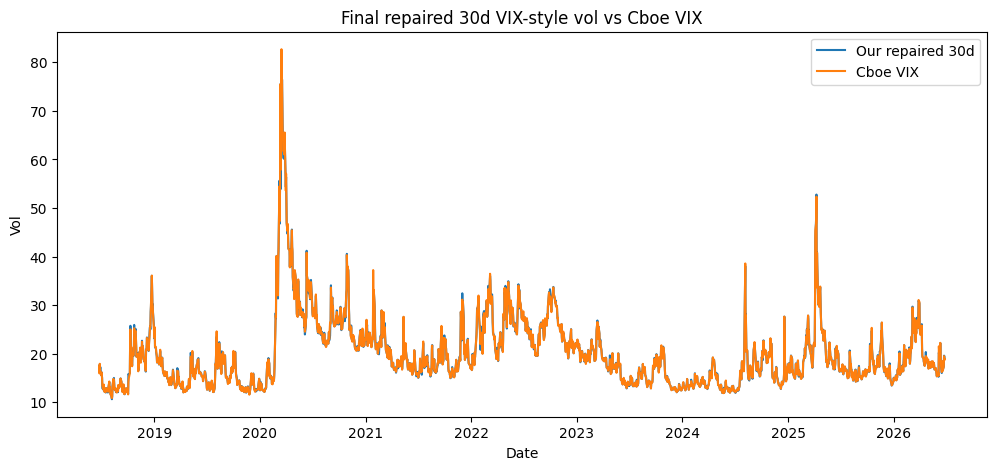

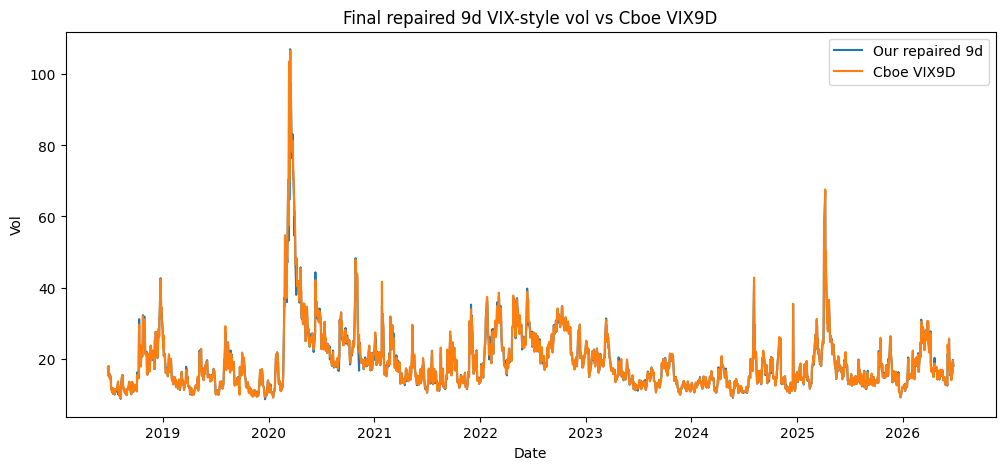

In [6]:
# ============================================================
# Plot benchmark comparisons
# ============================================================

vix_plot_df = vix_compare_df.copy()
vix_plot_df["date"] = pd.to_datetime(vix_plot_df["trade_date"].astype(str))

plt.figure(figsize=(12, 5))
plt.plot(vix_plot_df["date"], vix_plot_df["our_30d"], label="Our repaired 30d")
plt.plot(vix_plot_df["date"], vix_plot_df["vix_close"], label="Cboe VIX")
plt.title("Final repaired 30d VIX-style vol vs Cboe VIX")
plt.xlabel("Date")
plt.ylabel("Vol")
plt.legend()
plt.show()

vix9d_plot_df = vix9d_compare_df.copy()
vix9d_plot_df["date"] = pd.to_datetime(vix9d_plot_df["trade_date"].astype(str))

plt.figure(figsize=(12, 5))
plt.plot(vix9d_plot_df["date"], vix9d_plot_df["our_9d"], label="Our repaired 9d")
plt.plot(vix9d_plot_df["date"], vix9d_plot_df["vix9d_close"], label="Cboe VIX9D")
plt.title("Final repaired 9d VIX-style vol vs Cboe VIX9D")
plt.xlabel("Date")
plt.ylabel("Vol")
plt.legend()
plt.show()